In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [6]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

In [7]:
# Simple imputation using median
for col in cols_with_zeros:
    df[col] = df[col].fillna(df[col].median())

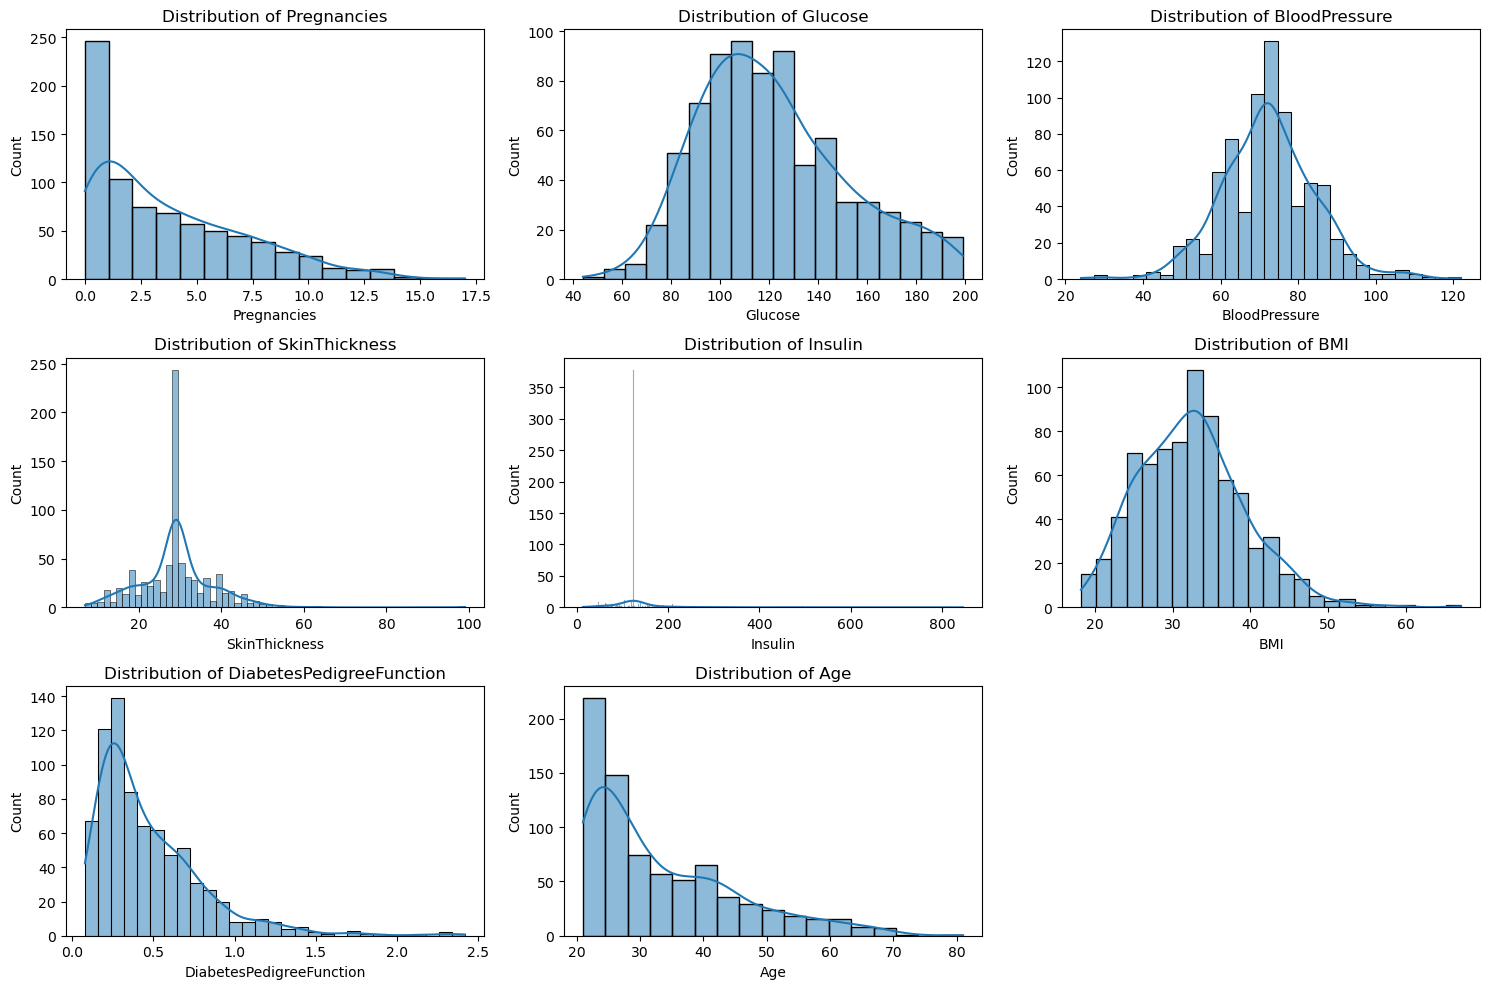

In [9]:
plt.figure(figsize=(15,10))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col],kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [11]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [15]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [16]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

Accuracy: 0.7532
Precision: 0.6667
Recall: 0.6182
F1 Score: 0.6415
ROC-AUC: 0.8228


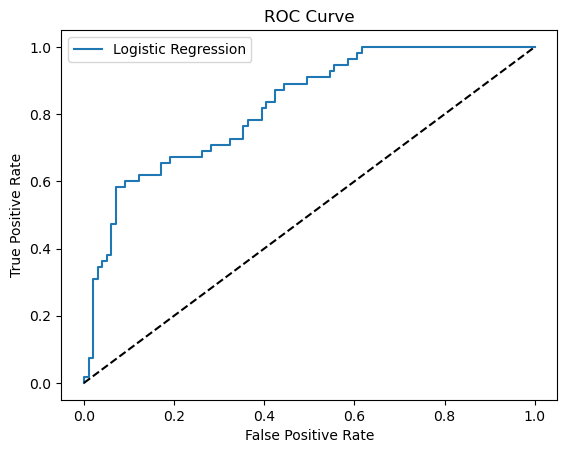

In [17]:
fpr ,tpr ,i = roc_curve(y_test,y_prob)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [18]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
print("\nFeature Significance:")
print(coef_df.sort_values(by='Coefficient', ascending=False))

# Export for Streamlit
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


Feature Significance:
                    Feature  Coefficient
1                   Glucose     1.102682
5                       BMI     0.688839
7                       Age     0.392410
0               Pregnancies     0.222978
6  DiabetesPedigreeFunction     0.203635
3             SkinThickness     0.068836
4                   Insulin    -0.138252
2             BloodPressure    -0.151540


In [19]:
import streamlit as st
import pandas as pd
import numpy as np
import pickle

In [20]:
model = pickle.load(open('model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

In [21]:
st.title("Diabetes Prediction App")
st.write("Enter the following details to predict the diabetes:")

2026-04-28 16:05:08.655 
  command:

    streamlit run C:\Users\HP\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]


In [22]:
# User inputs
pregnancies = st.number_input("Pregnancies", min_value=0, max_value=20, value=1)
glucose = st.number_input("Glucose", min_value=0, max_value=200, value=120)
bp = st.number_input("Blood Pressure", min_value=0, max_value=150, value=70)
skin = st.number_input("Skin Thickness", min_value=0, max_value=100, value=20)
insulin = st.number_input("Insulin", min_value=0, max_value=900, value=80)
bmi = st.number_input("BMI", min_value=0.0, max_value=70.0, value=30.0)
dpf = st.number_input("Diabetes Pedigree Function", min_value=0.0, max_value=3.0, value=0.5)
age = st.number_input("Age", min_value=1, max_value=120, value=30)

# Prediction

2026-04-28 16:05:28.127 Session state does not function when running a script without `streamlit run`


In [23]:
if st.button("Predict"):
    features = np.array([[pregnancies, glucose, bp, skin, insulin, bmi, dpf, age]])
    features_scaled = scaler.transform(features)
    prediction = model.predict(features_scaled)
    probability = model.predict_proba(features_scaled)[0][1]
    
    if prediction[0] == 1:
        st.error(f"High Risk of Diabetes (Probability: {probability:.2f})")
    else:
        st.success(f"Low Risk of Diabetes (Probability: {probability:.2f})")

### 1. What is the difference between precision and recall?

Precision : This is about being sure. If the model says, "You have diabetes," precision tells us how often it’s actually right. High precision means when the model rings the alarm, you can trust it. It’s all about avoiding False Positives—like telling a healthy person they are sick.

Recall : This is about being thorough. It asks, "Of everyone who actually has diabetes, how many did we catch?" High recall means you aren't letting anyone slip through the cracks. It’s about avoiding False Negatives—like telling a sick person they are perfectly fine.

### 2. What is cross-validation, and why is it important in binary classification?

Cross-Validation: Is a technique where the dataset is split into multiple folds. The model is trained on most folds and tested on the remaining one, repeating this process until every fold has been used as a test set.

Importance: It provides a more reliable estimate of model performance than a single train-test split. In binary classification, it ensures the model isn't just "lucky" on a specific slice of data and helps detect overfitting.